In [1]:
from platform import python_version
print(python_version())

3.11.14


In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as npmtd
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

sys.path.insert(1, '../src/')

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import *
from libs.MTD_lib import MTD
from libs.GDC_lib import GDC
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'TCGA-BRCA'
PSI_ID = 'TCGA-ACC'
PSI_ID = 'TCGA-CESC'
PSI_ID = 'TCGA-PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD/config/all_lfc_cutoffs_TCGA-PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=False, verbose=False)
# print("\nEcho Parameters:")
# print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD
>>> Tumor


### Get all programs

In [5]:
gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

#--------- chose a disease --------------------
DISEASE_ID = 'ACC'
DISEASE_ID = 'PAAD'

In [6]:
verbose=False
force=False

method='deseq2'
imax_tumor=250
imax_normal=50

gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

exclude_prog_list=['CCLE']

dfn_tumor, dfn_normal, df_gtex, df_ana = gdc.get_all_data_from_disease(disease_id=DISEASE_ID, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)
print("\n")
print(">> dfn_tumor", dfn_tumor.shape)
print(">> dfn_normal", dfn_normal.shape)

df_ana



>> dfn_tumor (60616, 460)
>> dfn_normal (60616, 103)


,prog_id,psi_id,disease_id,primary_site
0,CPTAC,PAAD,PAAD,Pancreas
1,CPTAC,PAAD_GDC,PAAD,Pancreas
2,TCGA,TCGA-PAAD,PAAD,Pancreas


In [7]:
dfn_tumor.head(3)

,geneid,symbol,biotype,1,2,3,4,5,6,7,...,448,449,450,451,452,453,454,455,456,457
0,ENSG00000000003,TSPAN6,protein_coding,18,0,6,2,7,0,4,...,1060,1221,210,18,155,36,84,182,323,192
1,ENSG00000000005,TNMD,protein_coding,39,23,3,15,13,13,10,...,0,1,87,4,2,0,1,8,1,0
2,ENSG00000000419,DPM1,protein_coding,48,11,13,5,27,5,5,...,1056,843,474,711,493,744,528,457,447,524


In [8]:
dfn_normal.head(3)

,geneid,symbol,biotype,1,2,3,4,5,6,7,...,91,92,93,94,95,96,97,98,99,100
0,ENSG00000000003,TSPAN6,protein_coding,1,1,0,1,0,2,1,...,0,0,1,1,1,1,0,2,0,0
1,ENSG00000000005,TNMD,protein_coding,7,10,14,3,7,14,5,...,11,13,3,9,16,12,17,9,7,9
2,ENSG00000000419,DPM1,protein_coding,6,3,2,2,0,6,8,...,11,4,6,9,7,5,15,5,1,9


### Clusterization

In [9]:
group = 'Tumor'

verbose=False
force=False

disease_id=DISEASE_ID
imax_tumor=250
imax_normal=50
exclude_prog_list=['CCLE']
n_components = 10
min_clusters = 6; max_clusters = 12
n_umap_neighbors=5; min_umap_dist=0.2; umap_metric="euclidean"
method_hca="ward"; hca_criterion="maxclust"
LFC_cutoff=1; FDR_cutoff=0.05
perc_min_samples=0.25; top_n=10_000

if group == 'Tumor':
    df = dfn_tumor
    n_clusters = 10
else:
    df = dfn_normal
    n_clusters = 3


df_cluster, df_sel, df_cpm, df_pca, df_umap = gdc.cluster_expression_data_group(df, group=group, n_clusters=n_clusters, 
                                                n_components=n_components, min_clusters=min_clusters, max_clusters=max_clusters,
                                                n_umap_neighbors=n_umap_neighbors, min_umap_dist=min_umap_dist, umap_metric=umap_metric,
                                                method_hca=method_hca, hca_criterion=hca_criterion,
                                                LFC_cutoff=LFC_cutoff, FDR_cutoff=FDR_cutoff,
                                                perc_min_samples=perc_min_samples, top_n=top_n,
                                                force=force, verbose=verbose)

### Batch effect

In [10]:
gdc.df_sel.T.shape, df_cpm.shape

((10000, 457), (20024, 457))

In [11]:
print(df_sel.T.shape)
df_sel.T.head(3)

(10000, 457)


,0,1,2,3,4,5,6,7,8,9,...,447,448,449,450,451,452,453,454,455,456
ENSG00000270641,14.479,13.720,14.420,13.992,14.229,12.156,13.862,13.964,13.765,13.668,...,9.388,0.107,9.473,0.350,0.339,9.473,5.700,0.359,8.507,0.339
ENSG00000262619,10.816,10.877,12.968,12.899,14.828,9.721,12.547,10.455,9.238,13.277,...,0.129,0.157,0.833,1.068,1.927,0.055,0.734,0.359,0.522,0.756
ENSG00000281383,3.418,0.000,10.809,0.000,11.366,5.782,3.113,0.000,0.000,0.759,...,0.248,0.206,0.135,0.242,0.885,0.301,0.000,0.249,0.000,0.398


In [12]:
dfc_log = np.log2(df_cpm + 1)  

gene_var = dfc_log.var(axis=1)

top_genes = (
    gene_var
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

dfc_log = dfc_log.loc[top_genes].copy()
print(len(dfc_log))
dfc_log.set_index(df_sel.T.index, inplace=True)
dfc_log.head(3)

10000


,1,2,3,4,5,6,7,8,9,10,...,448,449,450,451,452,453,454,455,456,457
ENSG00000270641,14.479,13.720,14.420,13.992,14.229,12.156,13.862,13.964,13.765,13.668,...,9.388,0.107,9.473,0.350,0.339,9.473,5.700,0.359,8.507,0.339
ENSG00000262619,10.816,10.877,12.968,12.899,14.828,9.721,12.547,10.455,9.238,13.277,...,0.129,0.157,0.833,1.068,1.927,0.055,0.734,0.359,0.522,0.756
ENSG00000281383,3.418,0.000,10.809,0.000,11.366,5.782,3.113,0.000,0.000,0.759,...,0.248,0.206,0.135,0.242,0.885,0.301,0.000,0.249,0.000,0.398


### Normal

In [13]:
dfn_normal.shape

(60616, 103)

In [14]:
dfn_normal.head(3)

,geneid,symbol,biotype,1,2,3,4,5,6,7,...,91,92,93,94,95,96,97,98,99,100
0,ENSG00000000003,TSPAN6,protein_coding,1,1,0,1,0,2,1,...,0,0,1,1,1,1,0,2,0,0
1,ENSG00000000005,TNMD,protein_coding,7,10,14,3,7,14,5,...,11,13,3,9,16,12,17,9,7,9
2,ENSG00000000419,DPM1,protein_coding,6,3,2,2,0,6,8,...,11,4,6,9,7,5,15,5,1,9


In [15]:
dfn_normal2 = dfn_normal[dfn_normal.geneid.isin(dfc_log.index.to_list())]
print(dfn_normal2.shape)
dfn_normal2.head(2)

(10000, 103)


,geneid,symbol,biotype,1,2,3,4,5,6,7,...,91,92,93,94,95,96,97,98,99,100
6,ENSG00000000971,CFH,protein_coding,23,5,4,6,5,1,0,...,10,1,12,8,0,8,3,9,11,6
8,ENSG00000001084,GCLC,protein_coding,4,7,0,3,3,3,1,...,3,0,4,0,2,5,39,3,4,1


In [16]:
gene_cols = ["geneid", "symbol", "biotype"]
sample_cols = [c for c in dfn_normal2.columns if c not in gene_cols]

dfn_normal3 = (
    dfn_normal2[sample_cols]
    .apply(pd.to_numeric, errors="coerce")  # non-numeric -> NaN
    .fillna(0)                              # NaN -> 0
).copy()

library_sizes = dfn_normal3.sum(axis=0)

df_cpm_nor = dfn_normal3.div(library_sizes, axis=1) * 1_000_000

dfc_log_nor = np.log2(df_cpm_nor + 1)

dfc_log_nor.set_index(dfn_normal2.geneid, inplace=True)

# dfc_log_nor = gdc.remove_to_big_bad_cols_expression(dfc_log_nor, nstd=2, msg='Normal')
# dfc_log_nor = gdc.remove_to_little_bad_cols_expression(dfc_log_nor, nstd=3, msg='Normal')

n_col_tumor = dfc_log.shape[1]
n_col_normal = dfc_log_nor.shape[1]

new_cols = np.arange(n_col_tumor+1, n_col_tumor+1+n_col_normal)
dfc_log_nor.columns = new_cols

dfc_log_nor.head(3)


,458,459,460,461,462,463,464,465,466,467,...,548,549,550,551,552,553,554,555,556,557
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000971,4.040,2.152,1.815,2.213,2.661,0.765,0.000,1.641,2.880,3.745,...,3.176,0.805,3.168,2.644,0.000,2.488,1.079,2.808,3.059,2.459
ENSG00000001084,1.882,2.542,0.000,1.495,2.069,1.631,0.861,1.641,2.471,2.184,...,1.770,0.000,1.873,0.000,1.393,1.956,3.950,1.585,1.874,0.807
ENSG00000001461,2.124,3.316,2.737,2.548,3.080,1.631,0.861,2.571,4.674,2.184,...,2.327,2.639,1.584,0.728,0.859,1.956,1.846,1.875,3.544,3.999


In [17]:
set_ndx_tumor = set(dfc_log.index)
set_ndx_normal = set(dfc_log_nor.index)

len(set_ndx_tumor - set_ndx_normal)

0

### Merge tumor + control without combat correction

In [18]:
dfn = pd.merge(dfc_log, dfc_log_nor, left_index=True, right_index=True, how='inner')
print(dfn.shape)

dfn.head(3)

(10000, 557)


,1,2,3,4,5,6,7,8,9,10,...,548,549,550,551,552,553,554,555,556,557
ENSG00000270641,14.479,13.720,14.420,13.992,14.229,12.156,13.862,13.964,13.765,13.668,...,3.042,3.204,5.332,2.484,3.808,4.869,13.583,4.755,3.841,14.448
ENSG00000262619,10.816,10.877,12.968,12.899,14.828,9.721,12.547,10.455,9.238,13.277,...,1.383,1.696,2.320,0.728,0.859,2.488,2.714,4.393,4.029,2.643
ENSG00000281383,3.418,0.000,10.809,0.000,11.366,5.782,3.113,0.000,0.000,0.759,...,0.000,0.000,0.000,0.000,0.000,0.000,1.312,0.000,0.737,0.000


In [19]:
dfn.columns = [int(x) for x in dfn.columns]
dfn.columns

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       548, 549, 550, 551, 552, 553, 554, 555, 556, 557],
      dtype='int64', length=557)

In [20]:
n_tumor_clusters = 10

force=False
verbose=verbose

dfn = gdc.calc_cpm_merge_turmor_and_normal(dfn_tumor=dfn_tumor, dfn_normal=dfn_normal,
                                         n_tumor_clusters=n_tumor_clusters, n_components = n_components,
                                         n_umap_neighbors=n_umap_neighbors, min_umap_dist=min_umap_dist, umap_metric=umap_metric,
                                         min_clusters=min_clusters, max_clusters=max_clusters,
                                         method_hca=method_hca, hca_criterion=hca_criterion,
                                         LFC_cutoff=LFC_cutoff, FDR_cutoff=FDR_cutoff,
                                         perc_min_samples=perc_min_samples, top_n=top_n,
                                         force=force, verbose=verbose)

dfn.columns = [int(x) for x in dfn.columns]

dfn.head(3)

,1,2,3,4,5,6,7,8,9,10,...,548,549,550,551,552,553,554,555,556,557
ENSG00000270641,14.479,13.720,14.420,13.992,14.229,12.156,13.862,13.964,13.765,13.668,...,3.042,3.204,5.332,2.484,3.808,4.869,13.583,4.755,3.841,14.448
ENSG00000262619,10.816,10.877,12.968,12.899,14.828,9.721,12.547,10.455,9.238,13.277,...,1.383,1.696,2.320,0.728,0.859,2.488,2.714,4.393,4.029,2.643
ENSG00000281383,3.418,0.000,10.809,0.000,11.366,5.782,3.113,0.000,0.000,0.759,...,0.000,0.000,0.000,0.000,0.000,0.000,1.312,0.000,0.737,0.000


In [21]:
n_sample_tumor_list = [31, 213, 213]
n_sample_control_list = [50, 50]


df_metadata = pd.DataFrame(
    {
        "condition": (
            ["tumor"] * n_sample_tumor_list[0]
            + ["tumor"] * n_sample_tumor_list[1]
            + ["tumor"] * n_sample_tumor_list[2]
            + ["normal"] * n_sample_control_list[0]
            + ["normal"] * n_sample_control_list[1]
        ),
        "dataset": (
            ["TCGA"] * n_sample_tumor_list[0]
            + ["CPTAC"] * n_sample_tumor_list[1]
            + ["CPTAC_GDC"] * n_sample_tumor_list[2]
            + ["CPTAC"] * n_sample_control_list[0]
            + ["CPTAC_GDC"] * n_sample_control_list[1]
        ),
    },
    index=[int(x) for x in dfn.columns],
)

df_metadata["condition_numeric"] = (
    df_metadata["condition"].eq("tumor").astype(float)
)

gdc.fname_metadata = 'metadata_tumor_and_normal.tsv'

_ = pdwritecsv(df_metadata, gdc.fname_metadata, gdc.root_mprog_lfc, verbose=True)


df_metadata.tail(3)

Table saved ((557, 3)) at '/home/flavio/uv/perturb_agent/data/multi_progs/lfc/metadata_tumor_and_normal.tsv'


,condition,dataset,condition_numeric
555,normal,CPTAC_GDC,0.0
556,normal,CPTAC_GDC,0.0
557,normal,CPTAC_GDC,0.0


In [22]:
df_metadata.index

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       548, 549, 550, 551, 552, 553, 554, 555, 556, 557],
      dtype='int64', length=557)

In [23]:
print(pd.crosstab(df_metadata["dataset"], df_metadata["condition"]))

condition  normal  tumor
dataset                 
CPTAC          50    213
CPTAC_GDC      50    213
TCGA            0     31


In [26]:
verbose=True
force=False

col_annots = ["geneid", "symbol", "biotype"]

df_gene_annot = (
    dfn_tumor[col_annots]
    .reset_index(drop=True)
)


df_combat = gdc.calc_combat_input_log_cpm(
    df_log_cpm=dfn,
    df_metadata=df_metadata,
    df_gene_annot=df_gene_annot,
    batch_col="dataset",
    covariates=["condition_numeric"],
    force=force,
    verbose=verbose,
)

Table opened ((10000, 560)) at '/home/flavio/uv/perturb_agent/data/multi_progs/lfc/combat_log_exp_tumor_and_normal.tsv'


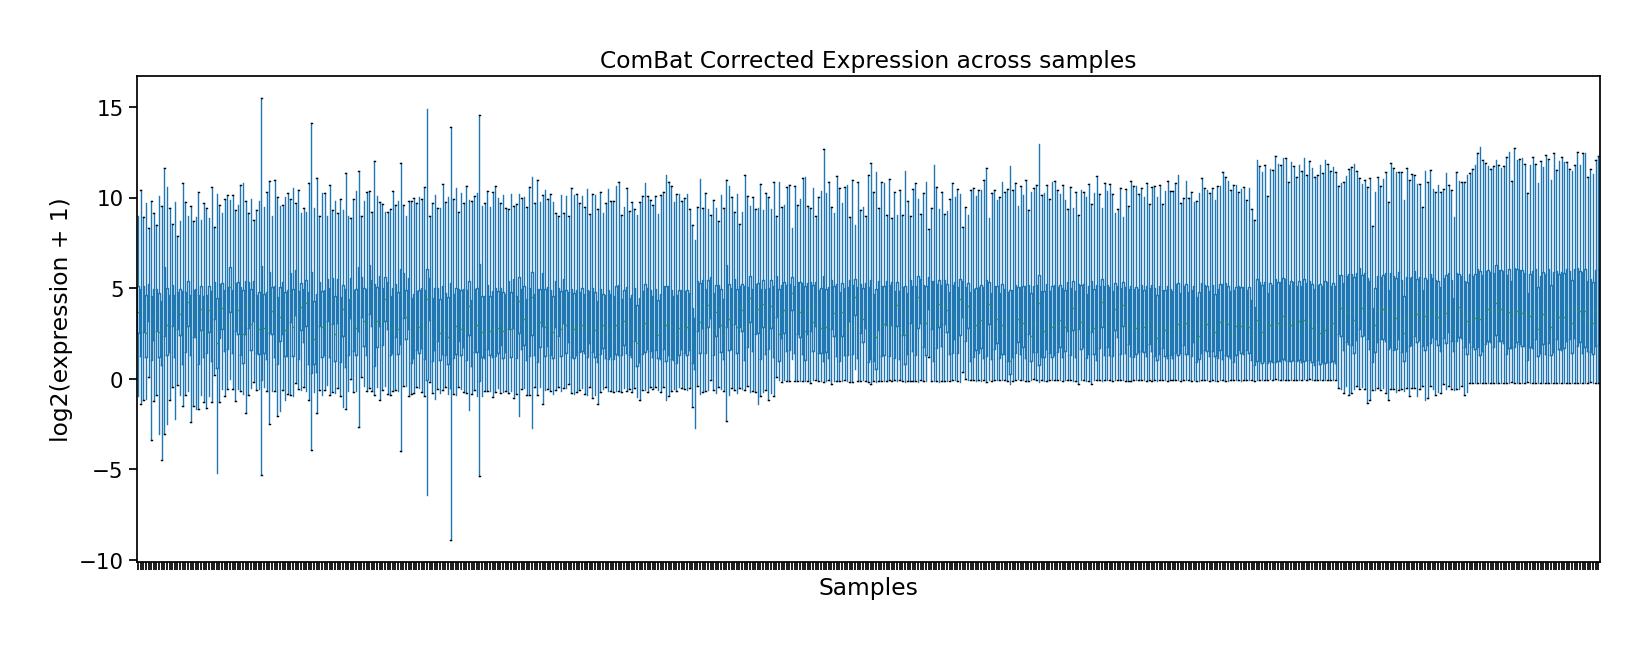

In [27]:
title = "ComBat Corrected Expression across samples"
figsize=(16, 6)

gdc.plot_boxplot_combat(df_combat=df_combat, title=title, figsize=figsize)


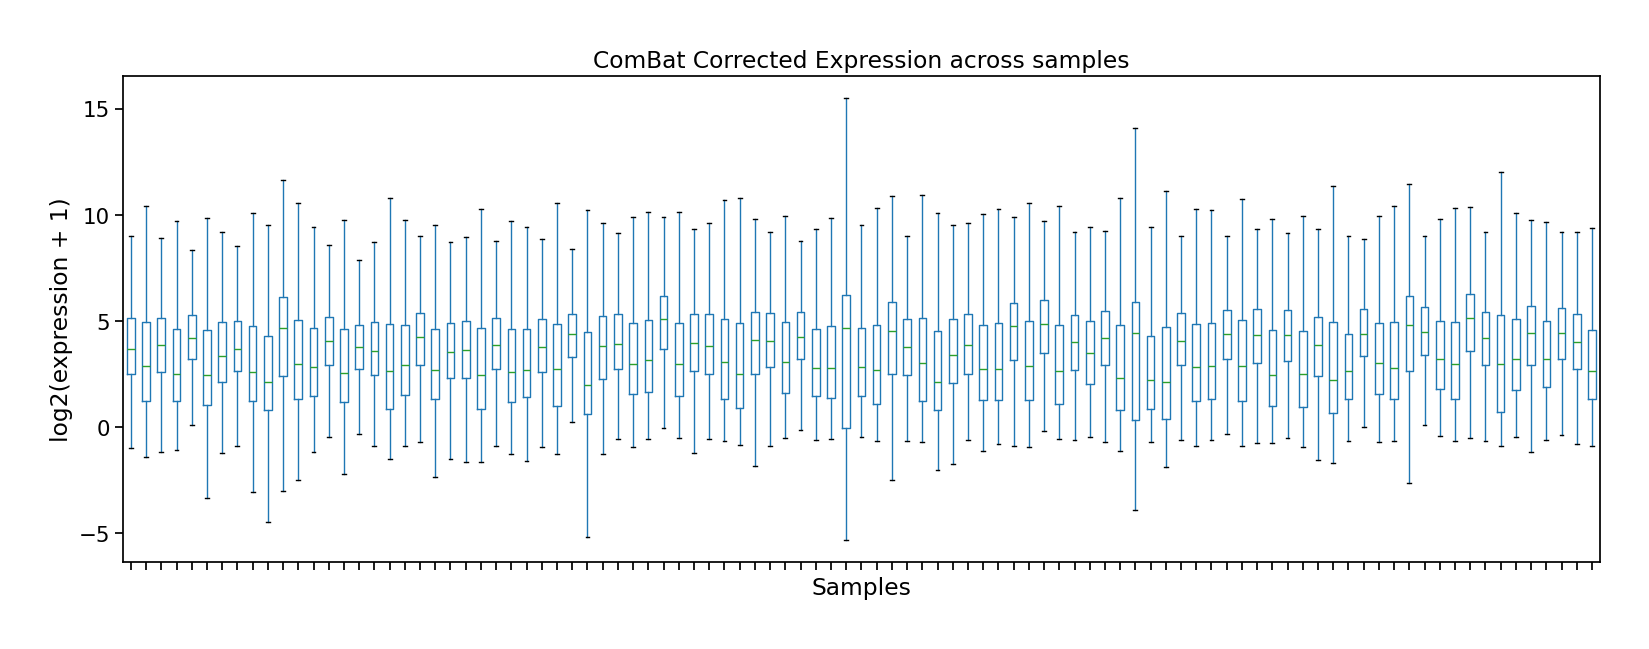

In [28]:
gdc.plot_boxplot_combat(df_combat=df_combat.iloc[:, 0:100], title=title, figsize=figsize)

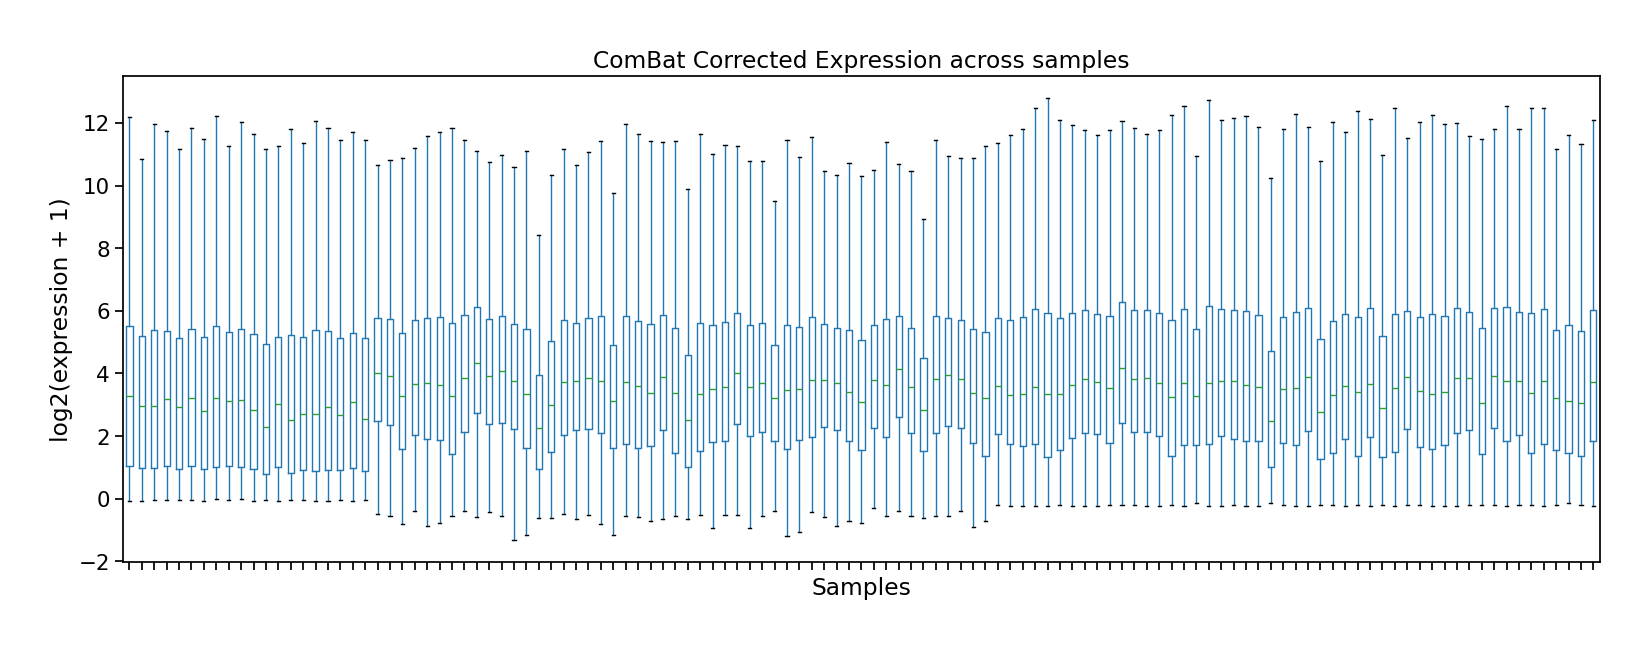

In [29]:
gdc.plot_boxplot_combat(df_combat=df_combat.iloc[:, -120:-1], title=title, figsize=figsize)

### PCA - Combat

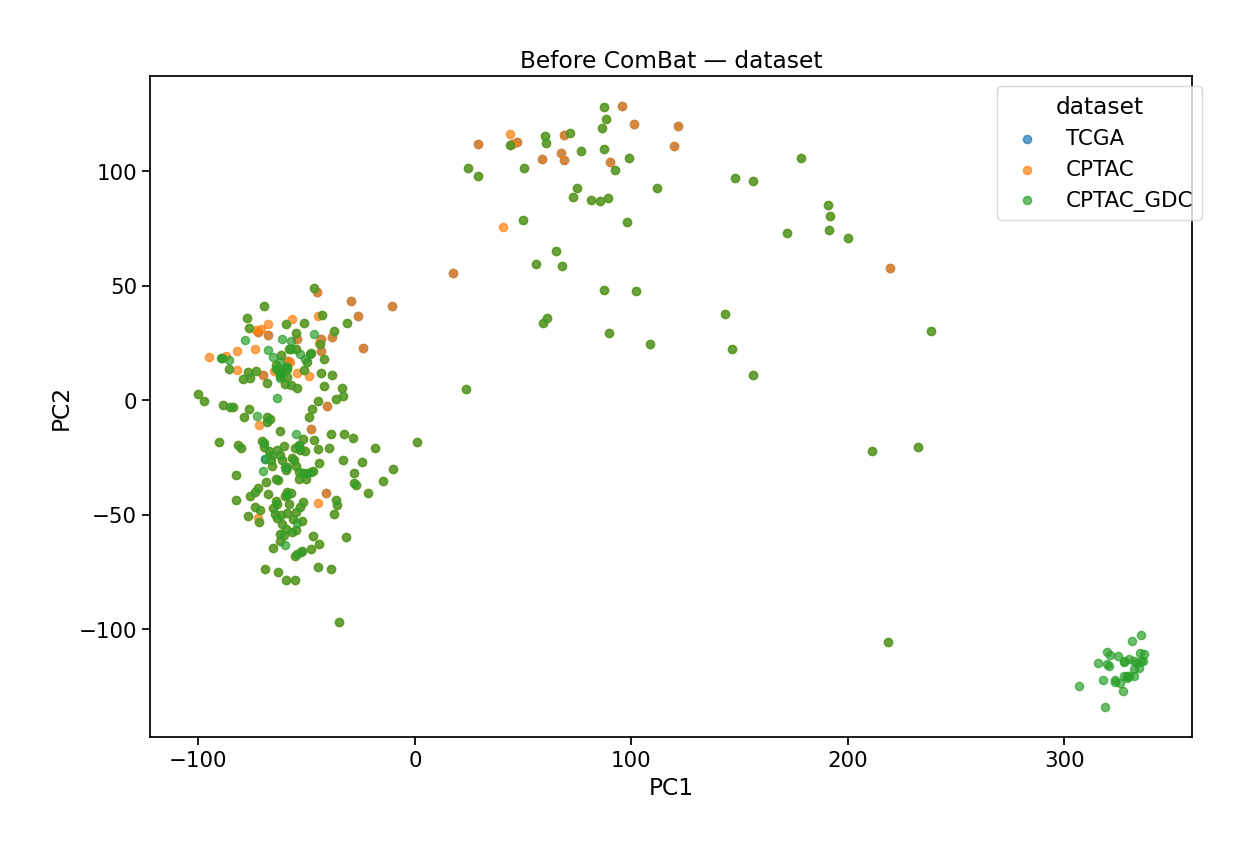

In [30]:
gdc.plot_pca_expression(
    dfn,
    df_metadata,
    color_col="dataset",
    title="Before ComBat — dataset",
    figsize=(12,8)
)

In [31]:
df_combat2 = df_combat.set_index('geneid').copy()
df_combat2 = df_combat2.iloc[:, 2:]
df_combat2.columns = [str(x) for x in df_combat2.columns]

df_combat2.columns = [int(x) for x in df_combat2.columns]

print(df_combat2.shape)
df_combat2.head(2)

(10000, 557)


,1,2,3,4,5,6,7,8,9,10,...,548,549,550,551,552,553,554,555,556,557
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000971,2.246,0.482,2.755,2.204,4.640,0.437,0.524,1.742,-0.027,0.753,...,2.887,0.824,2.881,2.424,0.124,2.288,1.062,2.567,2.785,2.263
ENSG00000001084,2.910,2.282,2.449,2.903,5.244,1.058,3.153,2.844,2.305,0.217,...,1.636,-0.035,1.732,-0.035,1.280,1.811,3.692,1.461,1.734,0.727


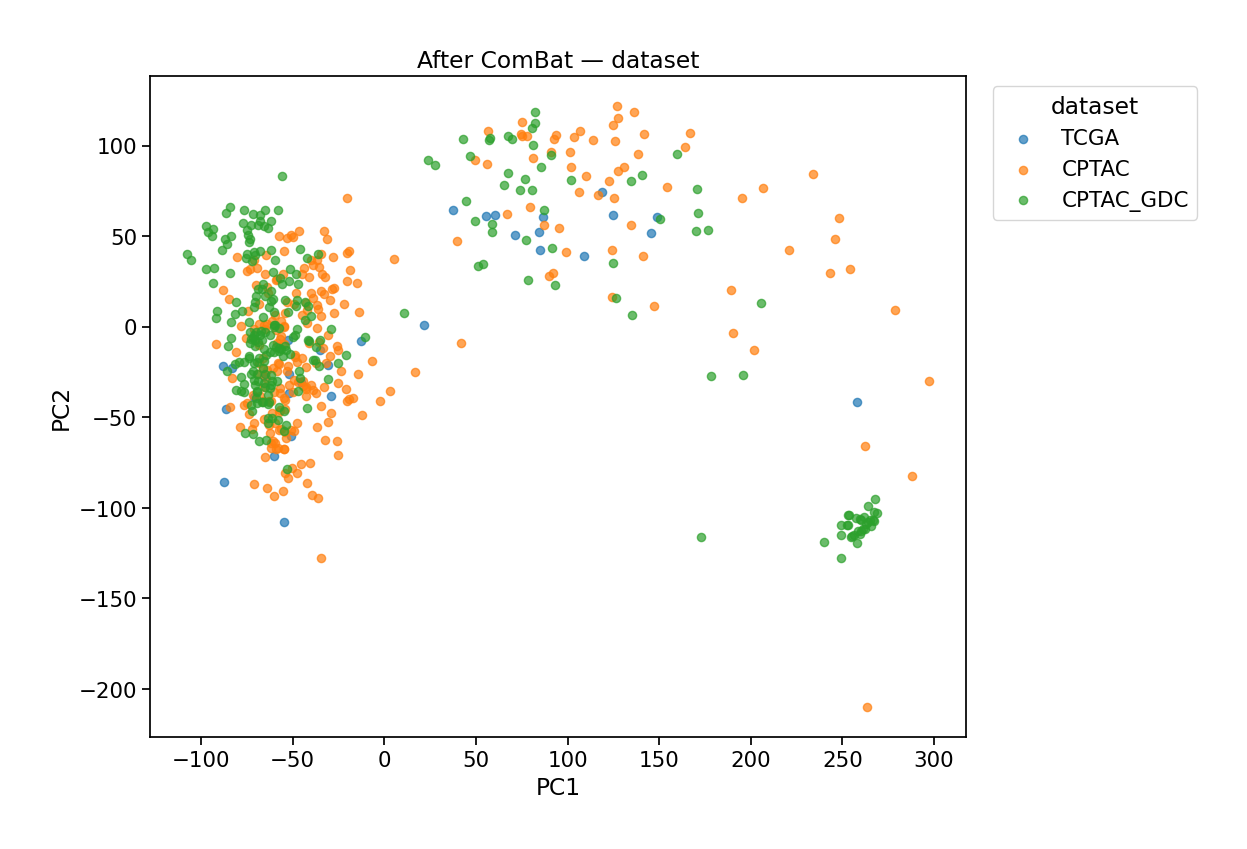

In [32]:
gdc.plot_pca_expression(
    df_combat2,
    df_metadata,
    color_col="dataset",
    title="After ComBat — dataset",
    figsize=(12,8)
)

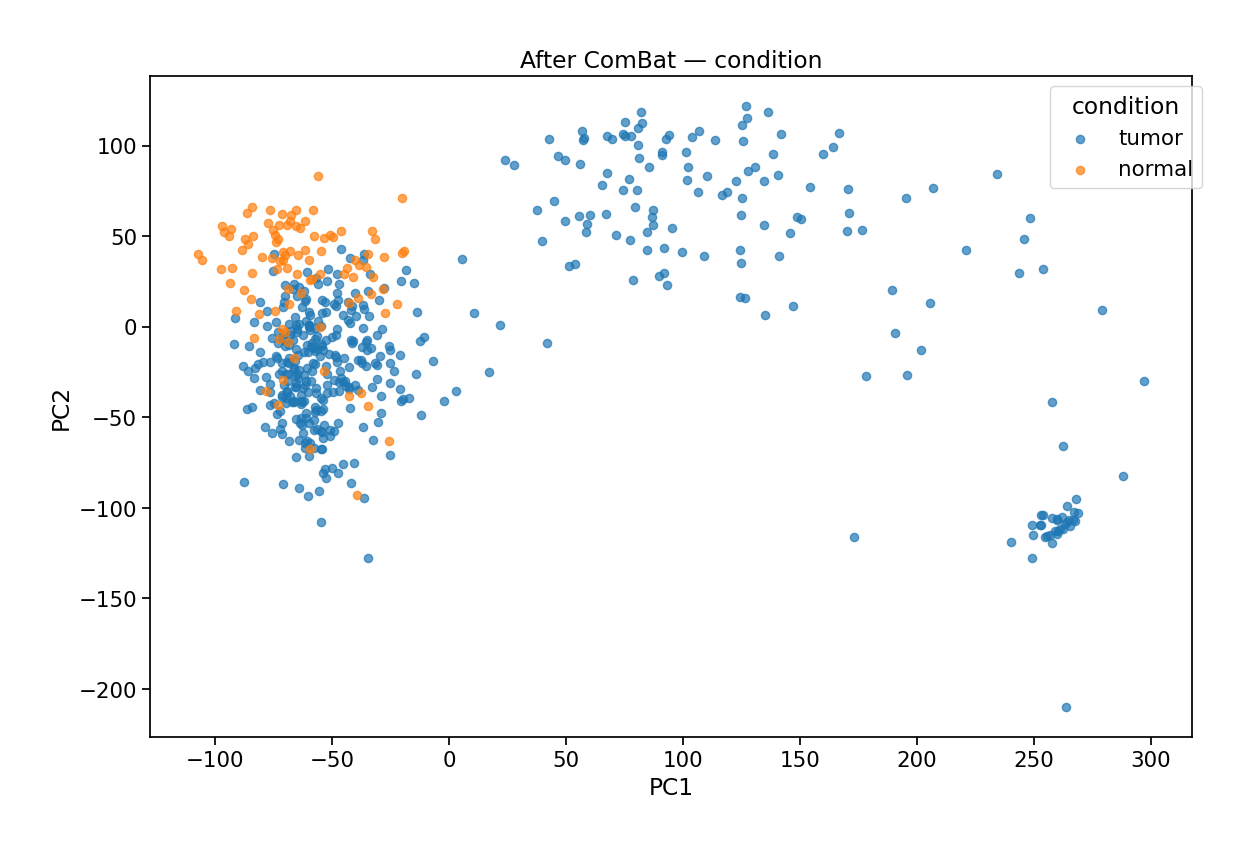

In [33]:
gdc.plot_pca_expression(
    df_combat2,
    df_metadata,
    color_col="condition",
    title="After ComBat — condition",
    figsize=(12,8)
)

### Cluster after Combat

In [36]:
df_combat_tumor = df_combat.iloc[:, :457+1]
df_combat_normal = df_combat.iloc[:, 457+1:]

df_combat_tumor.shape, df_combat_normal.shape


((10000, 458), (10000, 102))

In [37]:
df_combat_tumor.head(3)

,geneid,symbol,biotype,1,2,3,4,5,6,7,...,446,447,448,449,450,451,452,453,454,455
0,ENSG00000000971,CFH,protein_coding,2.246,0.482,2.755,2.204,4.640,0.437,0.524,...,5.536,6.096,6.626,2.020,5.315,2.518,5.244,3.516,4.707,3.852
1,ENSG00000001084,GCLC,protein_coding,2.910,2.282,2.449,2.903,5.244,1.058,3.153,...,4.786,4.726,3.902,4.229,4.954,4.894,5.568,4.960,6.787,6.101
2,ENSG00000001461,NIPAL3,protein_coding,4.104,4.274,2.748,0.284,2.603,0.484,2.438,...,4.615,5.124,4.172,5.429,4.843,4.945,4.659,6.292,5.212,4.797


In [38]:
df_combat_normal.head(3)

,456,457,458,459,460,461,462,463,464,465,...,548,549,550,551,552,553,554,555,556,557
0,5.421,2.474,4.674,2.379,1.969,2.453,2.998,0.692,-0.238,1.757,...,2.887,0.824,2.881,2.424,0.124,2.288,1.062,2.567,2.785,2.263
1,5.515,4.508,1.991,2.685,0.010,1.583,2.187,1.726,0.916,1.737,...,1.636,-0.035,1.732,-0.035,1.280,1.811,3.692,1.461,1.734,0.727
2,5.793,5.220,2.300,3.651,2.995,2.781,3.384,1.741,0.868,2.807,...,2.198,2.476,1.537,0.776,0.892,1.868,1.770,1.796,3.281,3.686


### PCA

In [39]:
gdc.df_pca

,PC1,PC2,PC3
0,4.495,63.019,-12.462
1,-36.287,22.011,-46.591
2,24.080,62.072,-13.044
3,-33.386,10.940,-38.871
4,42.726,73.060,-6.632
...,...,...,...
452,183.138,-61.941,-23.981
453,185.864,-62.813,-21.492
454,182.858,-65.070,-25.529
455,188.104,-64.790,-14.608


In [40]:
gdc.df_samp_clusters

,sample,cluster
0,0,3
1,1,4
2,2,3
3,3,4
4,4,3
...,...,...
452,452,2
453,453,2
454,454,2
455,455,2


In [41]:
gdc.df_samp_clusters.groupby('cluster').size()

cluster
1    202
2     33
3     78
4    102
5     24
6     18
dtype: int64

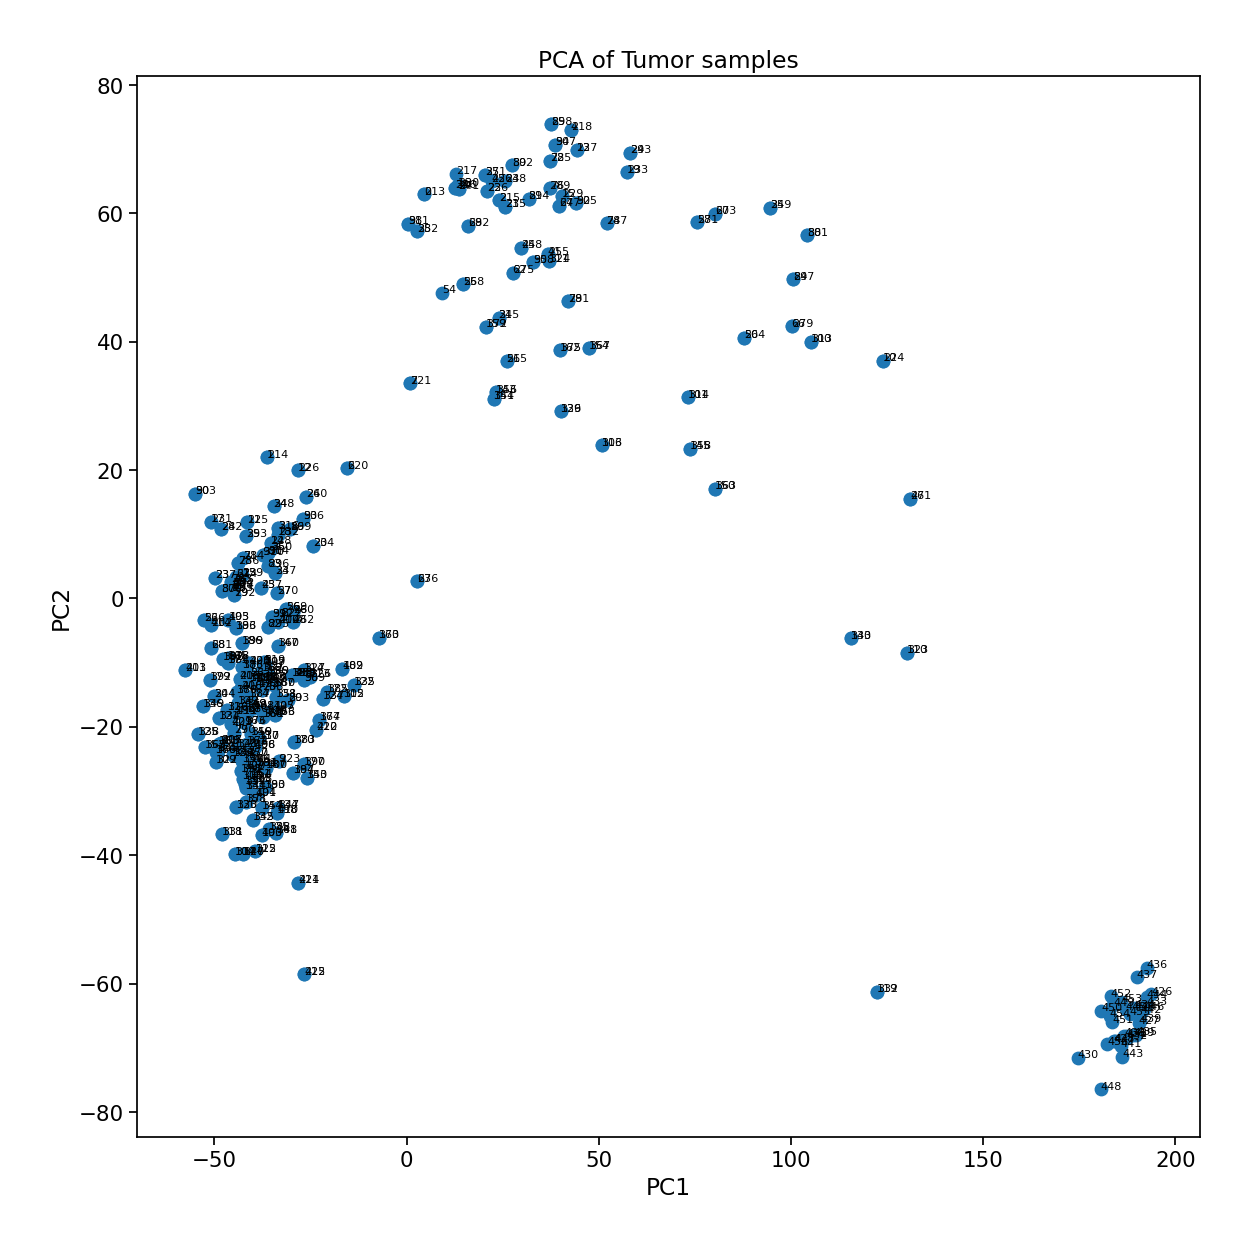

In [42]:
gdc.plot_PCA(df_pca, group=group, figsize=(12, 12))

### UMAP

In [43]:
df_umap.groupby('cluster').size()

cluster
1    202
2     33
3     78
4    102
5     24
6     18
dtype: int64

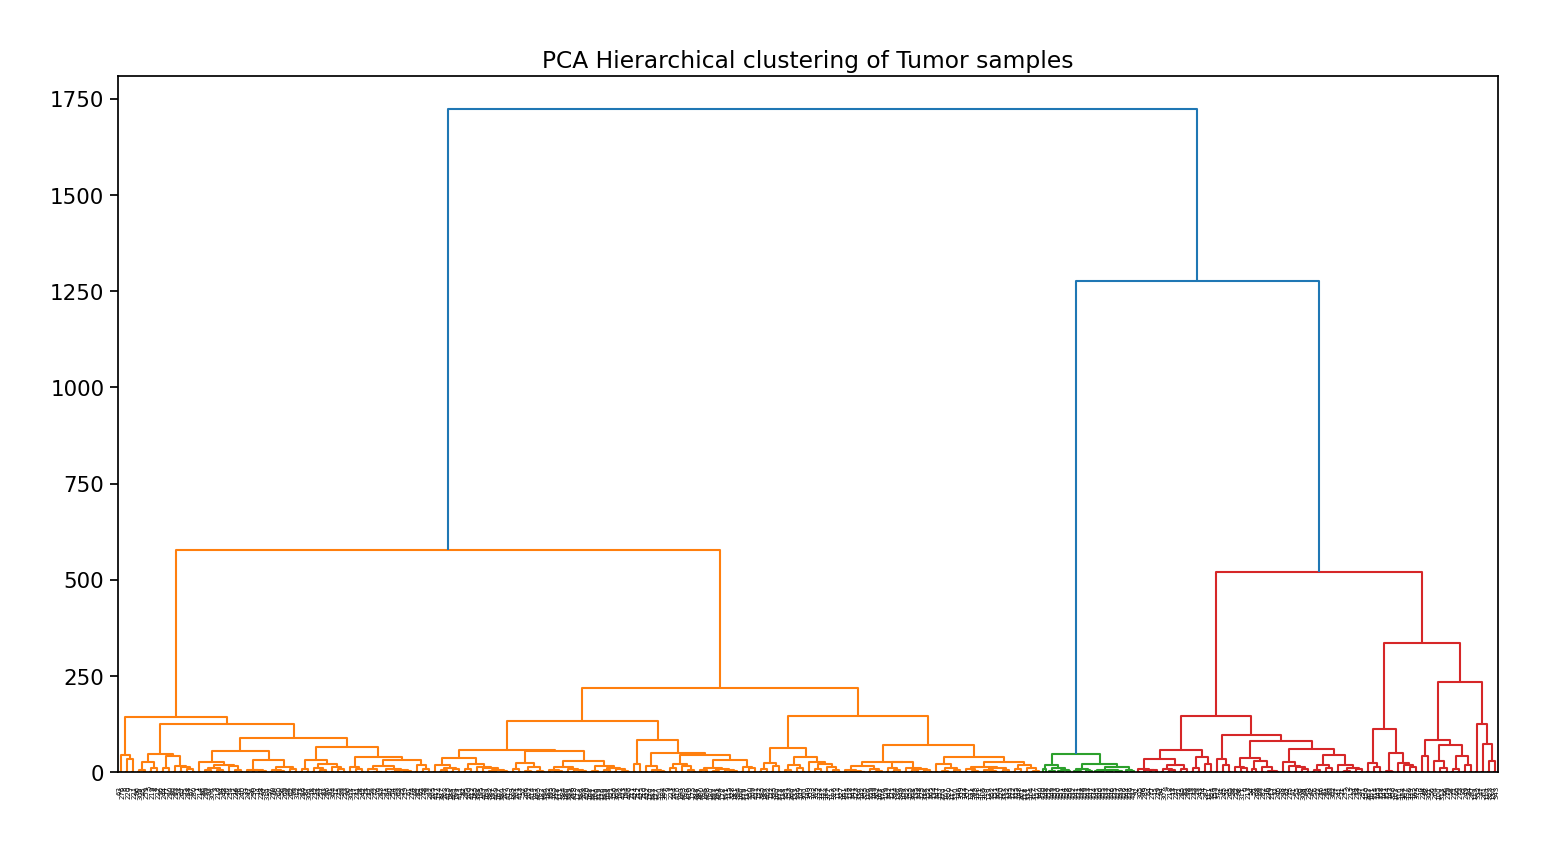

In [44]:
gdc.plot_HCA_PCA(df_pca, figsize=(15,8))

### Cut tree into k clusters:

In [45]:
gdc.df_hca

,sample,cluster
0,1,7
1,2,1
2,3,7
3,4,1
4,5,6
...,...,...
452,453,5
453,454,5
454,455,5
455,456,5


In [46]:
gdc.df_hca.groupby('cluster').size()

cluster
1     104
2     108
3      28
4      66
5      31
6      26
7      50
8      18
9      18
10      8
dtype: int64

In [48]:
dfc_log = np.log2(df_cpm + 1)

gene_annot = (
    gdc.dfg_filt[["geneid", "symbol"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

dfc_log.head(2)

,1,2,3,4,5,6,7,8,9,10,...,448,449,450,451,452,453,454,455,456,457
0,3.149,3.383,2.111,2.920,2.814,2.531,2.460,3.429,2.853,1.775,...,0.000,0.054,2.392,0.242,0.145,0.000,0.078,0.462,0.077,0.000
1,3.418,2.462,3.943,1.673,3.758,1.505,1.701,3.082,3.236,1.449,...,5.086,5.059,4.594,5.066,4.759,4.897,4.916,4.495,4.664,4.846


In [49]:
gdc.df_all_sign.head(3)

,geneid,cluster,n_in,n_out,mean_in,mean_out,lfc,pvalue,fdr,symbol
0,ENSG00000230535,1,104,353,9.564,3.275,6.289,9.965e-69,1.050e-65,BASP1P1
1,ENSG00000262619,1,104,353,11.497,5.285,6.212,6.212e-62,3.658e-59,LINC00621
2,ENSG00000189223,1,104,353,12.107,6.447,5.660,9.354e-80,1.561e-76,PAX8-AS1


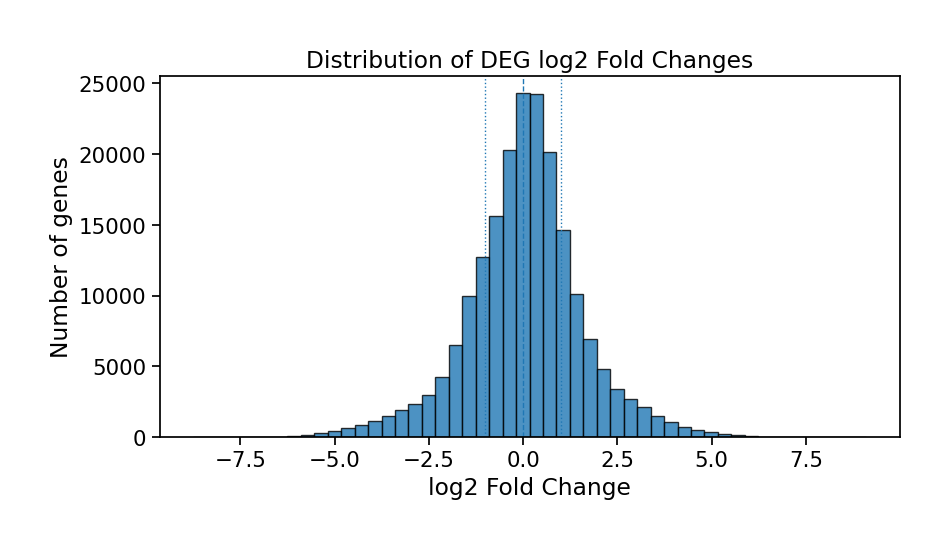

In [50]:
lfc = pd.to_numeric(gdc.df_all_sign["lfc"], errors="coerce").dropna().to_list()

gdc.plot_histogram(data=lfc, title="Distribution of DEG log2 Fold Changes", bins=50, 
                   xlabel="log2 Fold Change", ylabel="Number of genes",
                   figsize=(9, 5))

In [51]:
cluster_list = np.unique(gdc.df_all_sign.cluster)
cluster_list

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [52]:
ncluster = 1

df2 = gdc.df_sig_sign
df2.head(3)

,geneid,cluster,n_in,n_out,mean_in,mean_out,lfc,pvalue,fdr,symbol
0,ENSG00000230535,1,104,353,9.564,3.275,6.289,9.965e-69,1.050e-65,BASP1P1
1,ENSG00000262619,1,104,353,11.497,5.285,6.212,6.212e-62,3.658e-59,LINC00621
2,ENSG00000189223,1,104,353,12.107,6.447,5.660,9.354e-80,1.561e-76,PAX8-AS1


In [53]:
df3 = df2[df2.cluster == ncluster]
df3 = df3[ (df3['lfc'].abs() >= LFC_cutoff) & (df3['fdr'] < FDR_cutoff) ]
print(len(df3))
df3.head(3)

2038


,geneid,cluster,n_in,n_out,mean_in,mean_out,lfc,pvalue,fdr,symbol
0,ENSG00000230535,1,104,353,9.564,3.275,6.289,9.965e-69,1.050e-65,BASP1P1
1,ENSG00000262619,1,104,353,11.497,5.285,6.212,6.212e-62,3.658e-59,LINC00621
2,ENSG00000189223,1,104,353,12.107,6.447,5.660,9.354e-80,1.561e-76,PAX8-AS1


In [54]:
dic = {}

for ncluster in cluster_list:
    df3 = df2[df2.cluster == ncluster]
    df3 = df3[ (df3['lfc'].abs() >= LFC_cutoff) & (df3['fdr'] < FDR_cutoff) ]

    symbols = np.unique(df3.symbol)

    dic[ncluster] = set(symbols)

    print(f"Cluster {ncluster}: {len(symbols)} signature genes")



Cluster 1: 2032 signature genes
Cluster 2: 1621 signature genes
Cluster 3: 1566 signature genes
Cluster 4: 1952 signature genes
Cluster 5: 6494 signature genes
Cluster 6: 6995 signature genes
Cluster 7: 5313 signature genes
Cluster 8: 5662 signature genes
Cluster 9: 6987 signature genes
Cluster 10: 3159 signature genes


### UMAP

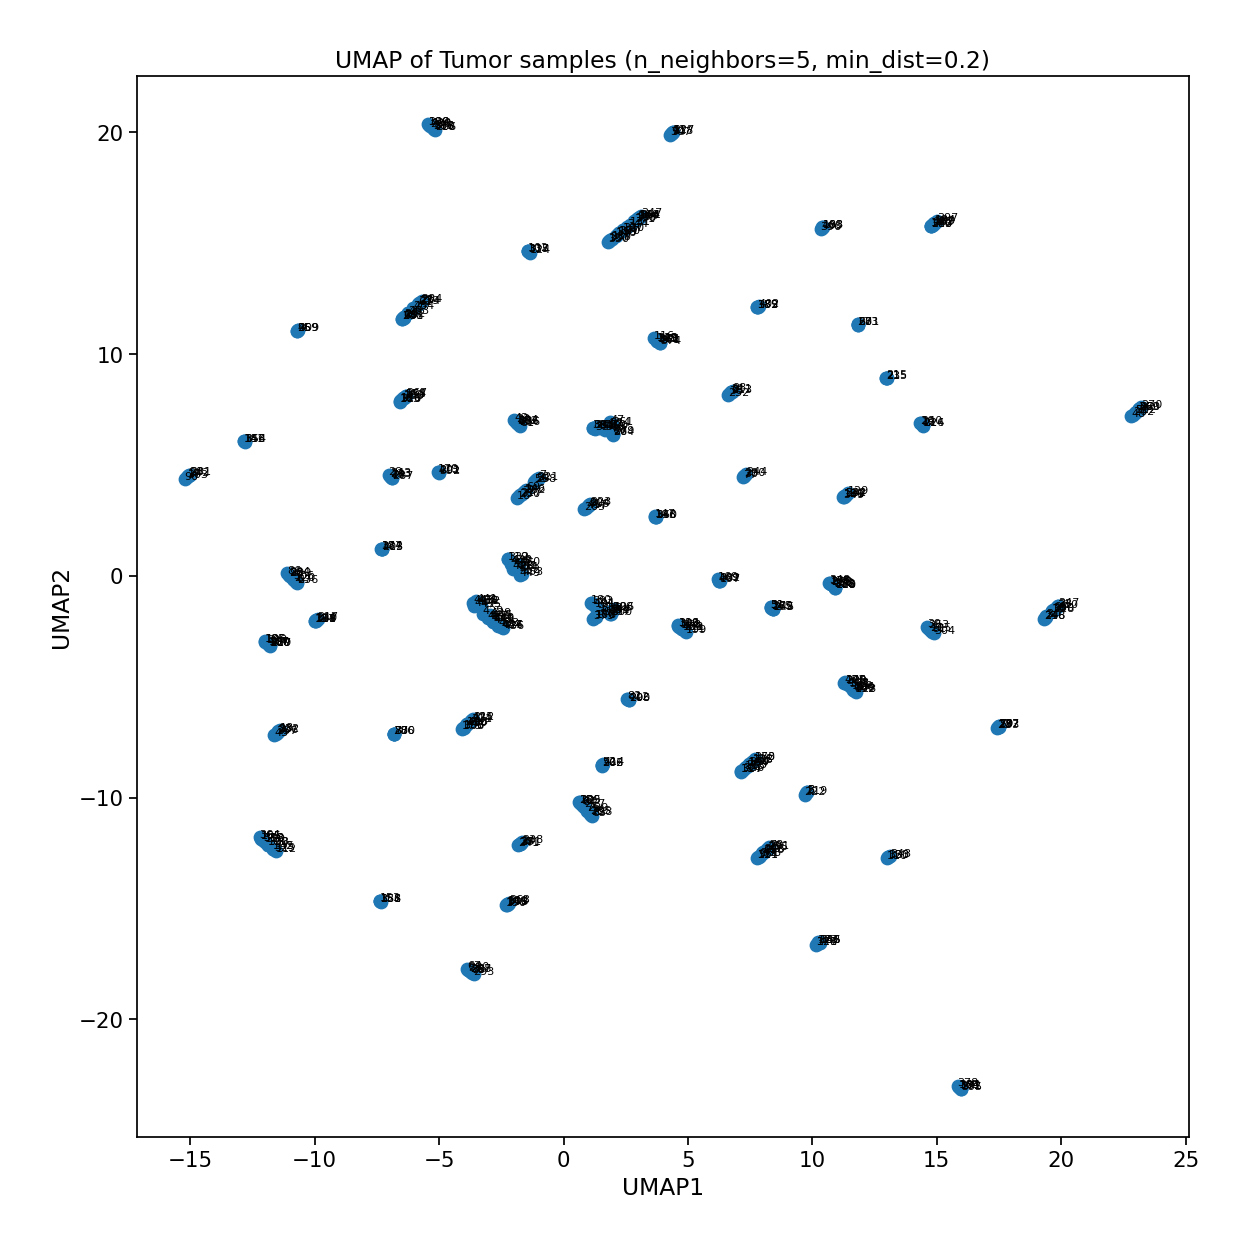

In [55]:
n_neighbors=5
min_dist=0.2
metric="euclidean"

gdc.plot_PCA_UMAP(df_umap=df_umap, n_neighbors=n_neighbors, min_dist=min_dist, figsize=(12, 12))

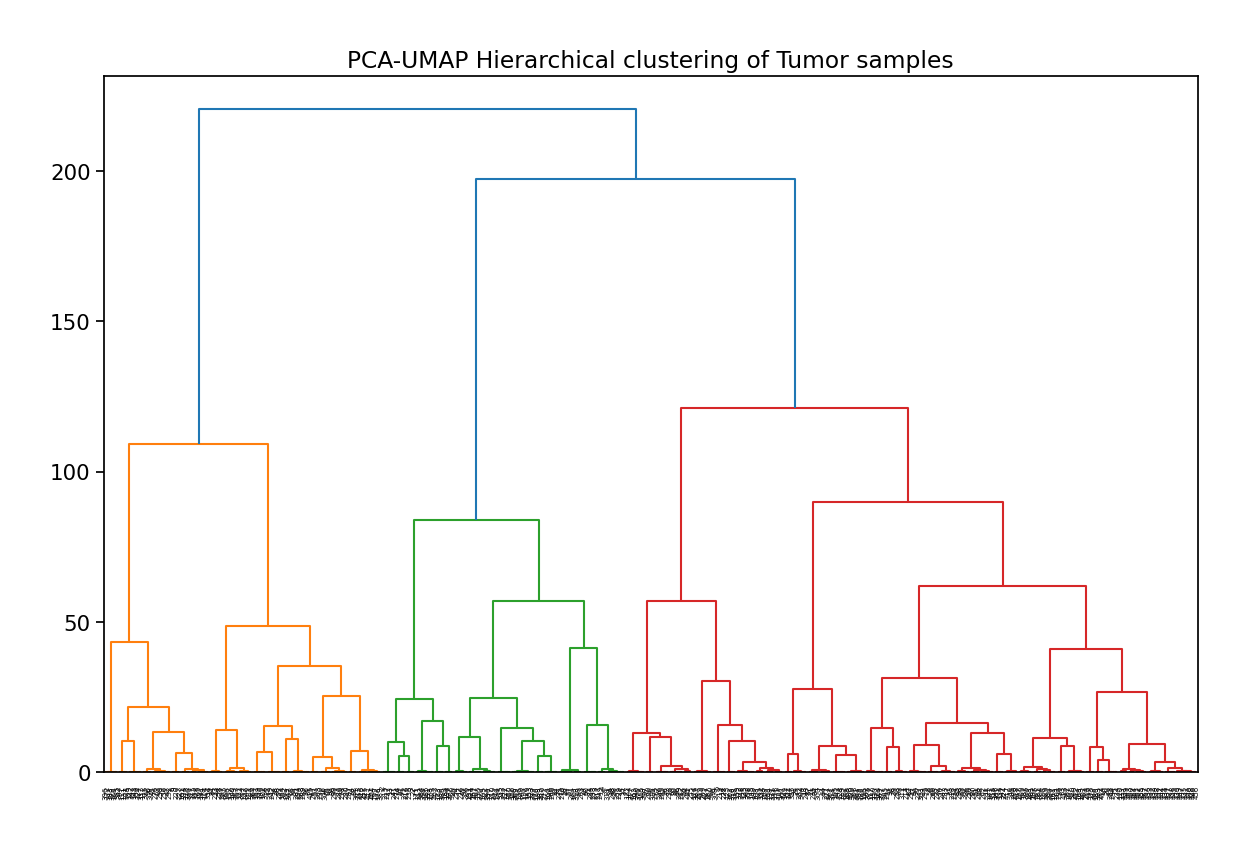

In [56]:
gdc.plot_HCA_PCA_UMAP(df_umap, figsize=(12, 8))

### Development & tests

In [ ]:
import scanpy as sc
from anndata import AnnData

def calc_combat_input_log_cpm(
    df_log_cpm,
    df_metadata,
    batch_col="dataset",
    covariates=None,
):
    import numpy as np
    import pandas as pd
    import scanpy as sc
    from anndata import AnnData

    expression = df_log_cpm.copy()
    df_metadata = df_metadata.copy()
    covariates = covariates or []

    original_columns = expression.columns.copy()
    original_index = expression.index.copy()

    missing_samples = expression.columns.difference(df_metadata.index)

    if len(missing_samples) > 0:
        raise ValueError(
            f"Samples missing from df_metadata: "
            f"{missing_samples[:10].tolist()}"
        )

    df_metadata = df_metadata.loc[expression.columns].copy()

    expression = expression.apply(
        pd.to_numeric,
        errors="coerce",
    )

    if expression.isna().any().any():
        raise ValueError(
            "Expression contains missing or non-numeric values."
        )

    keep_genes = expression.var(axis=1) > 0
    expression_filtered = expression.loc[keep_genes]

    print(
        f"ComBat input: {expression_filtered.shape[0]:,} genes × "
        f"{expression_filtered.shape[1]:,} samples"
    )
    print(
        f"Removed {(~keep_genes).sum():,} zero-variance genes."
    )

    adata = AnnData(
        X=expression_filtered.T.to_numpy(dtype=np.float64),
        obs=df_metadata.copy(),
        var=pd.DataFrame(index=expression_filtered.index),
    )

    adata.obs[batch_col] = (
        adata.obs[batch_col].astype("category")
    )

    for covariate in covariates:
        if pd.api.types.is_numeric_dtype(
            adata.obs[covariate]
        ):
            adata.obs[covariate] = (
                adata.obs[covariate].astype(float)
            )

    corrected_array = sc.pp.combat(
        adata,
        key=batch_col,
        covariates=covariates or None,
        inplace=False,
    )

    corrected = pd.DataFrame(
        corrected_array.T,
        index=expression_filtered.index,
        columns=original_columns,
    )

    return corrected

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def plot_pca_expression(
    df_logexp: pd.DataFrame,
    df_metadata: pd.DataFrame,
    color_col:str,
    title:str,
    figsize:tuple=(12,8)
):
    metadata_aligned = df_metadata.loc[df_logexp.columns]

    X = df_logexp.T.to_numpy()

    coordinates = PCA(n_components=2).fit_transform(X)

    fig, ax = plt.subplots(figsize=figsize)

    for group in metadata_aligned[color_col].unique():
        mask = metadata_aligned[color_col].eq(group).to_numpy()

        ax.scatter(
            coordinates[mask, 0],
            coordinates[mask, 1],
            label=str(group),
            alpha=0.7,
            s=35,
        )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.legend(title=color_col, bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()